# Exploratory Data Analysis (EDA)
- Statistical Analysis
- Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load Cleaned Data
data = pd.read_csv(r"D:\ML_Project\fraud_detection_analysis\data\Fraud_Analysis_Cleaned_Dataset.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [3]:
df = data.copy()

In [4]:
# # Statistical Analysis
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


### Visualization

### Target distribution

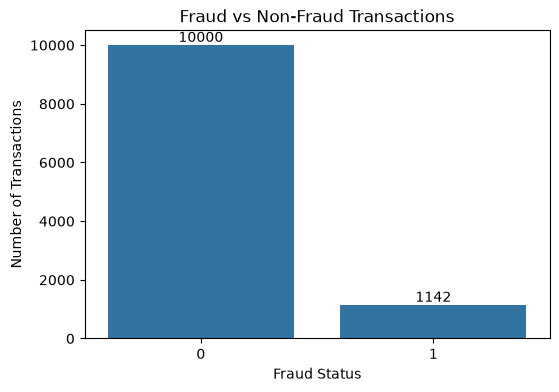

In [5]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = "isFraud", data = df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

- The target variable is highly imbalanced, so we use **class_weight="balanced"** to give more importance to fraudulent transactions during model training.

In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')

### Fraud count by transaction type

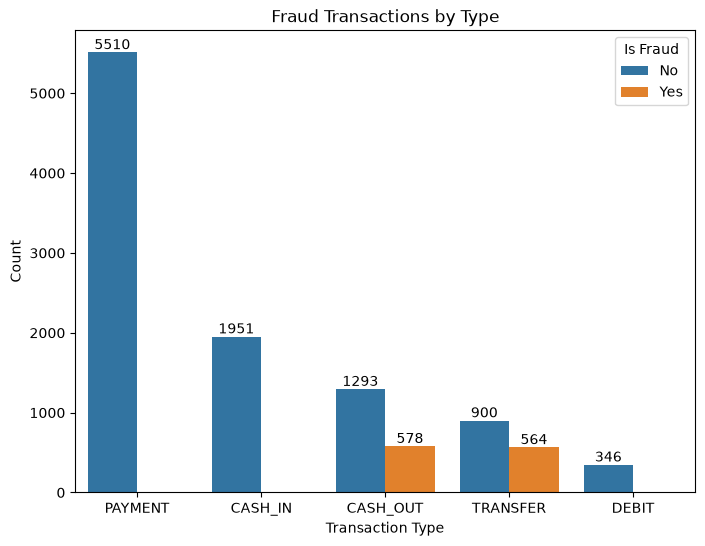

In [7]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x="type", hue="isFraud", data = df, order = df["type"].value_counts().index)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(title="Is Fraud", labels=["No", "Yes"])

plt.show()

### Check Skewness

In [8]:
num_cols = df.select_dtypes(include = 'number')
skew_data = num_cols.skew()
print(skew_data)

step              3.584856
amount            8.392241
oldbalanceOrg     2.837205
newbalanceOrig    2.910317
oldbalanceDest    4.125516
newbalanceDest    3.681198
isFraud           2.621568
dtype: float64


- We can see that most numerical features are **highly right-skewed**. So, we use `np.log1p()` to reduce the skewness and make the data more suitable for **Logistic Regression** and **SVM**, which can be sensitive to skewness and feature scaling.

Tree-based models like **Random Forest, Gradient Boosting, and XGBoost** are generally less affected by skewed data, but transforming the features can still help our **Logistic Regression baseline** and **SVM**.

- There is no need to transform the skewed data because we are also using **tree-based models**, which can handle skewed features well.
- Skewed data does not always need transformation, especially when using **tree-based models** that can handle skewed features well.

### Transaction amount distribution (LOG SCALE)

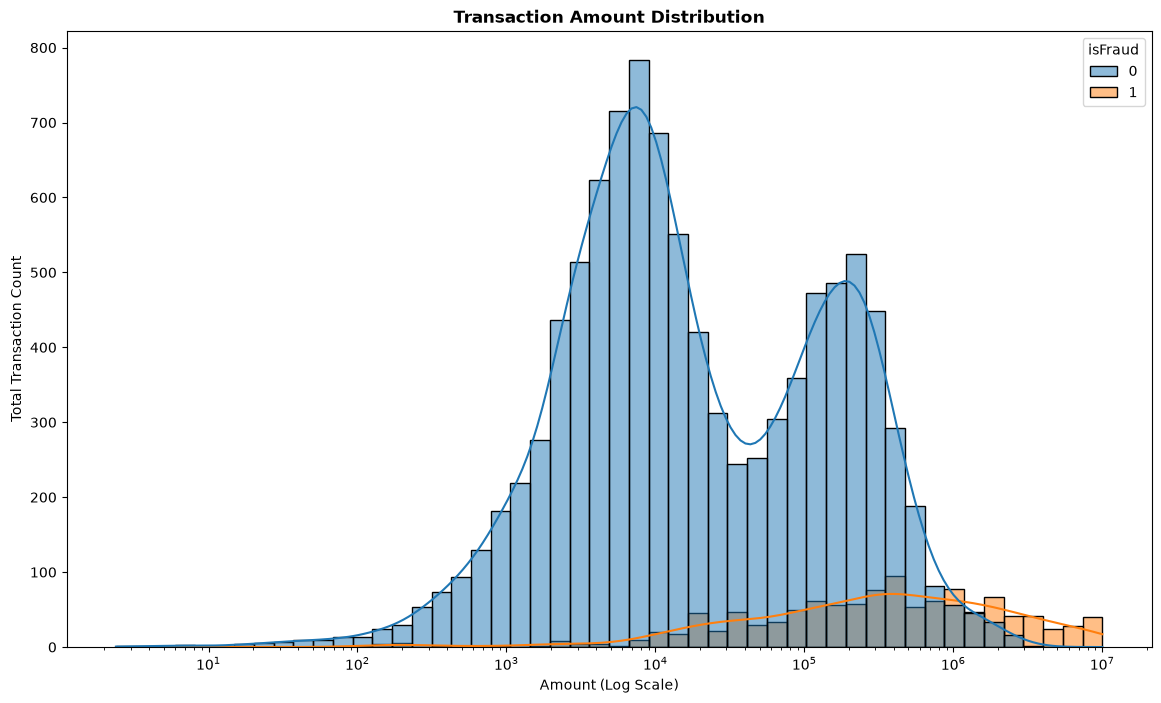

In [9]:
plt.figure(figsize=(14, 8))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=50,
    kde=True,
    log_scale=True,

)

plt.title("Transaction Amount Distribution", fontweight="bold")
plt.xlabel("Amount (Log Scale)")
plt.ylabel("Total Transaction Count")

plt.show()

### Fraud Transaction over step(Time)

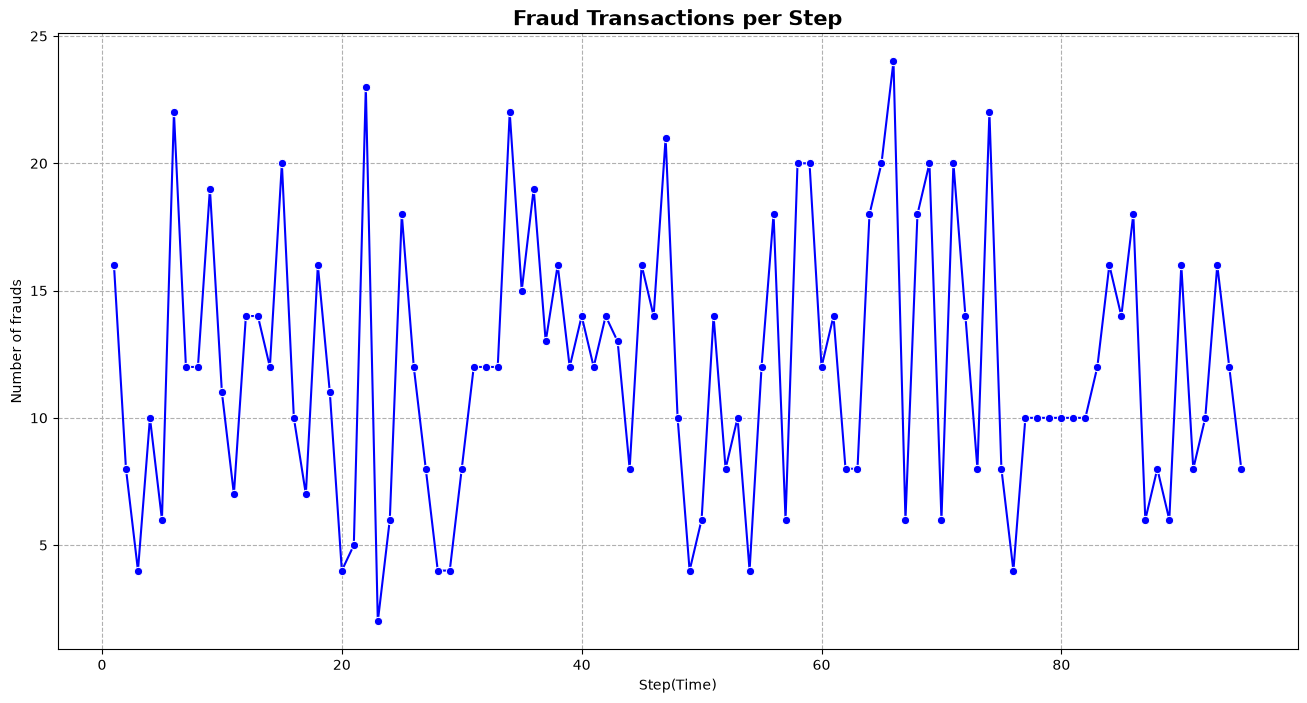

In [10]:
plt.figure(figsize=(16, 8))

fraud_by_step = df.groupby("step")["isFraud"].sum().reset_index()

sns.lineplot(data = fraud_by_step, x="step", y="isFraud", color="blue", marker="o")

plt.title("Fraud Transactions per Step", fontweight="bold", fontsize=15)
plt.xlabel("Step(Time)")
plt.ylabel("Number of frauds")
plt.grid(True, linestyle="--", alpha=1)

plt.show()

### Fraud Rate by transaction type

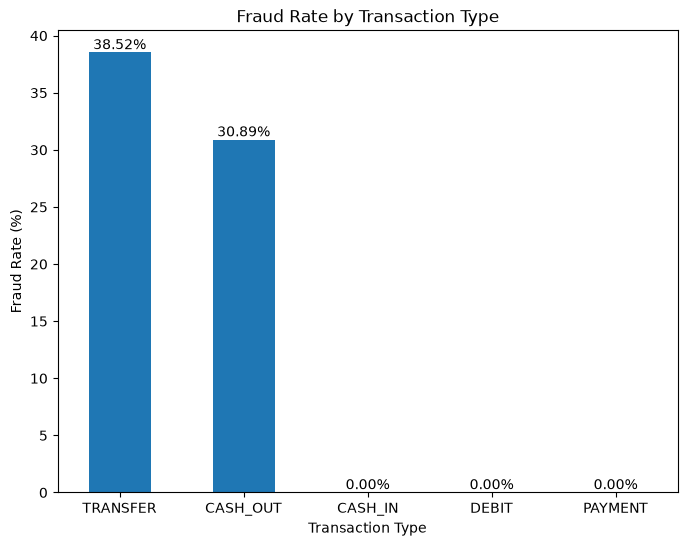

In [11]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

ax = fraud_rate_by_type.plot(
        kind="bar",
        figsize=(8, 6),
    )

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")
    
plt.title("Fraud Rate by Transaction Type")
plt.xticks(rotation = 0)
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

- We observ that here the fraud only happens in TRANSFER and CASH_OUT

D:\ML_Project\fraud_detection_analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
D:\ML_Project\fraud_detection_analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
D:\ML_Project\fraud_detection_analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
D:\ML_Project\fraud_detection_analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


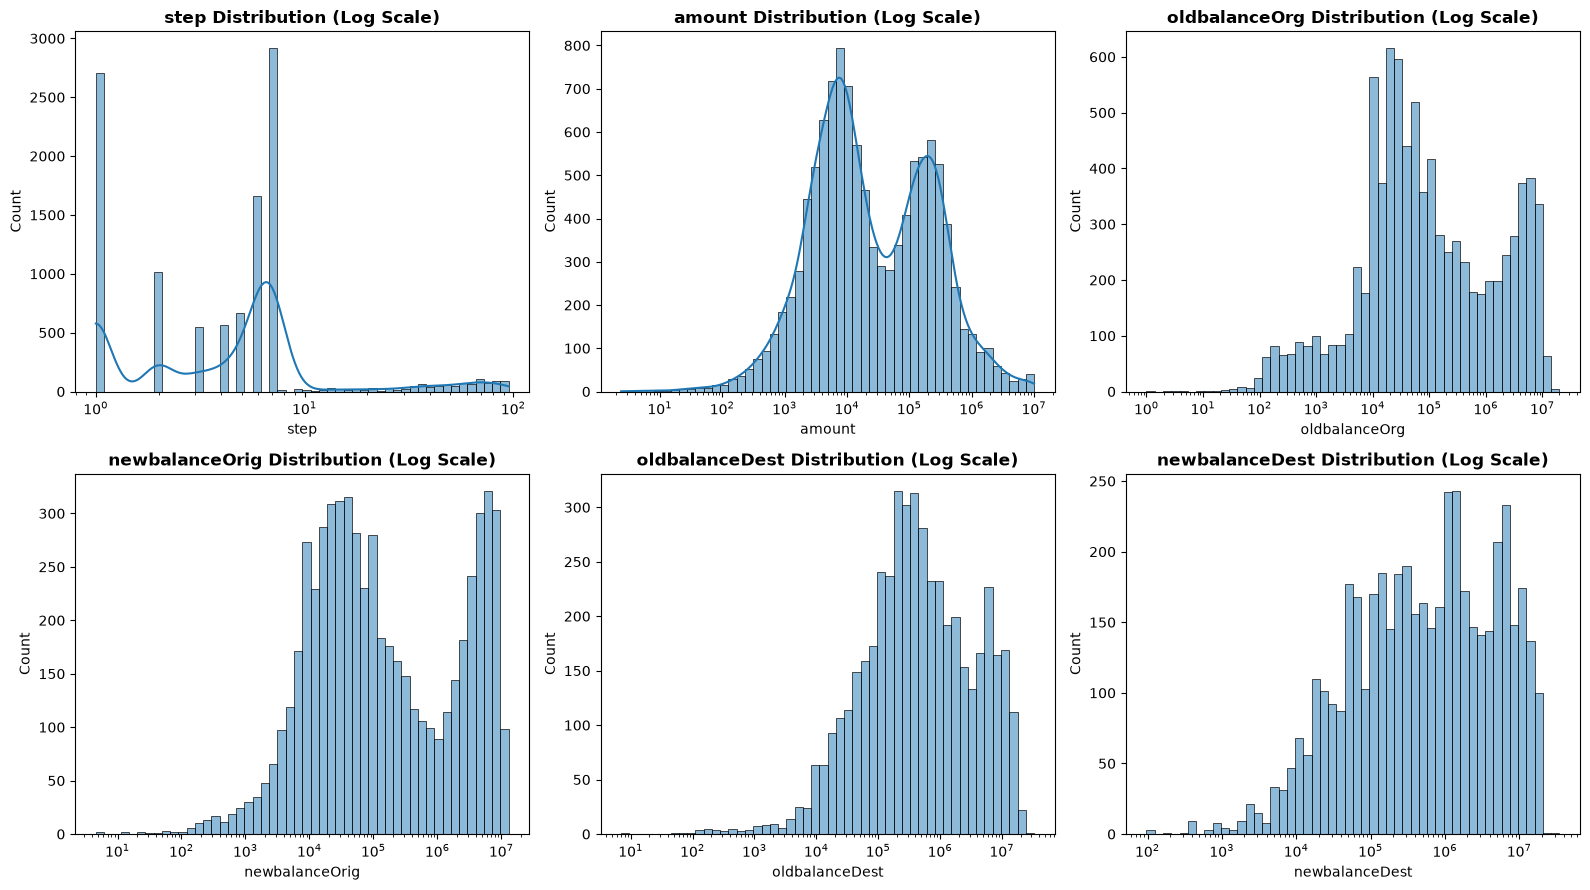

In [12]:
skewed_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

plt.figure(figsize=(16, 9))

for i, col in enumerate(skewed_cols, 1):
  plt.subplot(2, 3, i)

  # Added log_scale=True back and specified a clean color (no palette warning)
  sns.histplot(
      data=df, x=col, kde=True, bins=50, log_scale=True
  )

  plt.title(f"{col} Distribution (Log Scale)", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

### target vs Numeric feature

In [13]:
numeric_columns = df.select_dtypes(include = 'number').columns.to_list()
numeric_columns.remove('isFraud')

In [14]:
numeric_columns

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest']

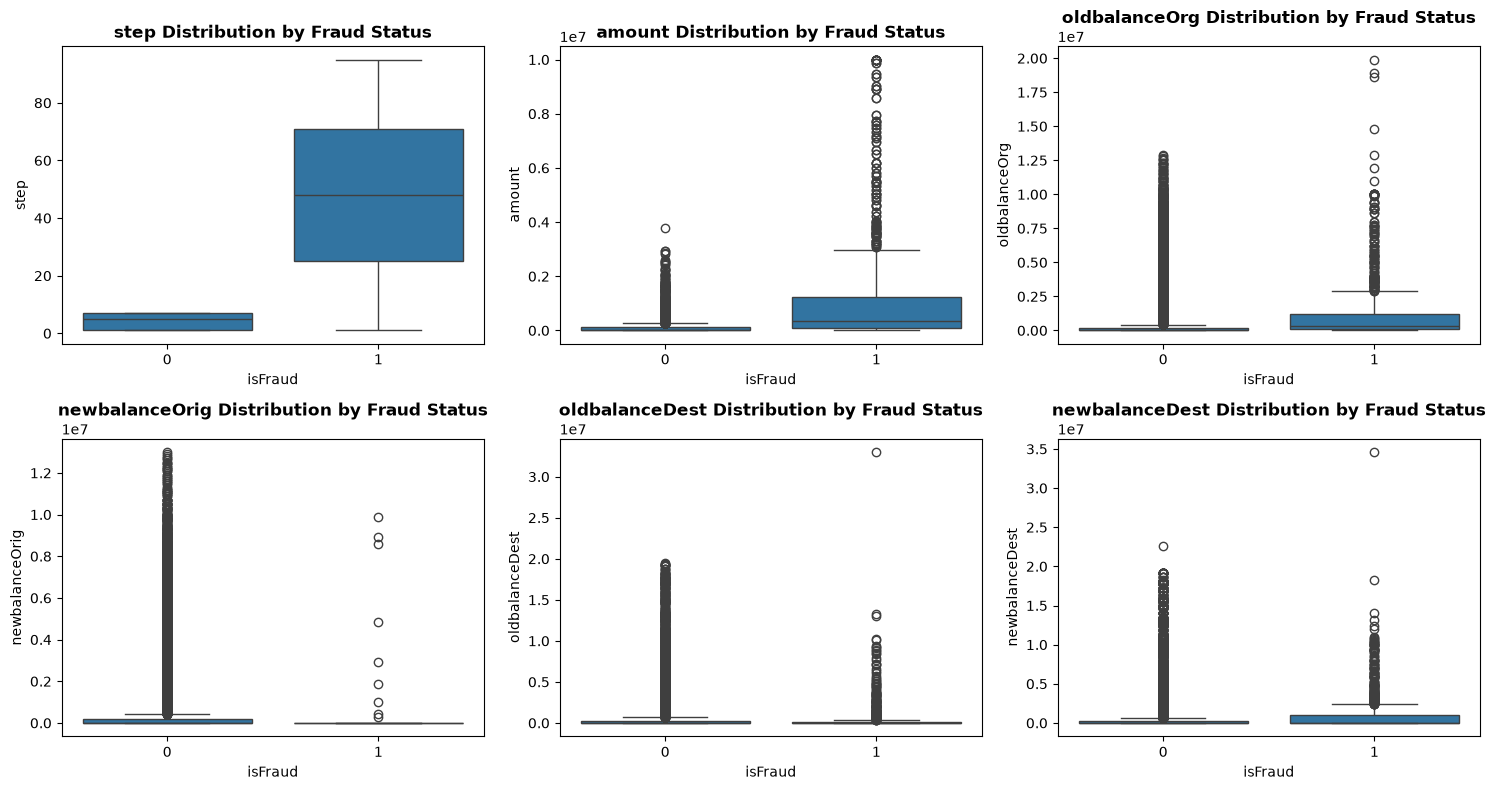

In [15]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x = "isFraud", y = col)
    plt.title(f"{col} Distribution by Fraud Status", fontweight="bold")

plt.tight_layout()
plt.show()





**Outliers matter** in fraud detection because they can represent unusual transaction behavior, which may be a sign of fraud.

### Correlation Analysis

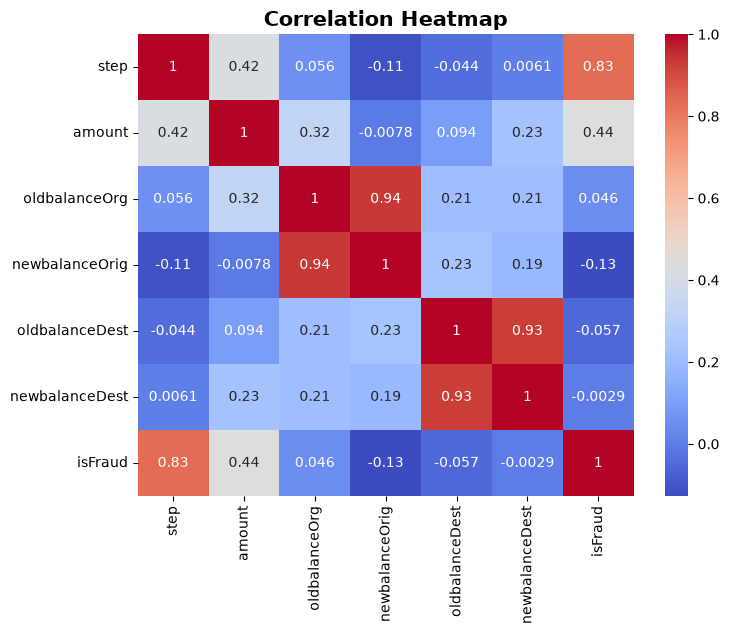

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only = True), annot = True, cmap="coolwarm")

plt.title("Correlation Heatmap", fontweight = "bold", fontsize = 15)
plt.show()